# Students Grading Dataset — Data Preprocessing Project

This notebook performs data preprocessing on the **Students_Grading_Dataset_Biased.csv** dataset.

Included steps:
- Data cleaning
- Attribute subset selection
- Data transformation
- Data discretization
- Normalization
- Export of the preprocessed dataset


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


In [7]:
df = pd.read_csv("/Users/shynmere/Desktop/data_mining_project_mereke_tor/Students_Grading_Dataset_Biased.csv")
df.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


In [8]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())

Shape: (5000, 23)

Missing values:
Student_ID                       0
First_Name                       0
Last_Name                        0
Email                            0
Gender                           0
Age                              0
Department                       0
Attendance (%)                 516
Midterm_Score                    0
Final_Score                      0
Assignments_Avg                517
Quizzes_Avg                      0
Participation_Score              0
Projects_Score                   0
Total_Score                      0
Grade                            0
Study_Hours_per_Week             0
Extracurricular_Activities       0
Internet_Access_at_Home          0
Parent_Education_Level        1794
Family_Income_Level              0
Stress_Level (1-10)              0
Sleep_Hours_per_Night            0
dtype: int64


## Data Cleaning and Attribute Subset Selection

In [9]:
df_clean = df.drop(columns=["Student_ID", "First_Name", "Last_Name", "Email"])

df_clean["Attendance (%)"] = df_clean["Attendance (%)"].fillna(df_clean["Attendance (%)"].median())
df_clean["Assignments_Avg"] = df_clean["Assignments_Avg"].fillna(df_clean["Assignments_Avg"].median())
df_clean["Parent_Education_Level"] = df_clean["Parent_Education_Level"].fillna(df_clean["Parent_Education_Level"].mode()[0])

if df_clean["Participation_Score"].max() <= 10:
    df_clean["Participation_Score"] *= 10

print("Remaining missing:", df_clean.isna().sum().sum())
df_clean.head()

Remaining missing: 0


,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,Female,22,Engineering,52.29,55.03,57.82,84.22,74.06,39.9,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,Male,18,Engineering,97.27,97.23,45.80,74.81,94.24,83.2,55.65,50.64,A,19.0,No,Yes,PhD,Medium,4,9.0
2,Male,24,Business,57.19,67.05,93.68,67.70,85.70,50.5,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,Female,24,Mathematics,95.15,47.79,80.63,66.06,93.51,65.4,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,Female,23,CS,54.18,46.59,78.89,96.85,83.70,59.7,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


In [10]:
print("Shape:", df_clean.shape)

Shape: (5000, 19)


## Data Transformation

In [11]:
df_transformed = df_clean.copy()

df_transformed["Gender"] = df_transformed["Gender"].map({"Male": 0, "Female": 1})
df_transformed["Extracurricular_Activities"] = df_transformed["Extracurricular_Activities"].map({"No": 0, "Yes": 1})
df_transformed["Internet_Access_at_Home"] = df_transformed["Internet_Access_at_Home"].map({"No": 0, "Yes": 1})

df_transformed["Grade"] = pd.Categorical(df_transformed["Grade"], ["F", "D", "C", "B", "A"], ordered=True).codes
df_transformed["Parent_Education_Level"] = pd.Categorical(
    df_transformed["Parent_Education_Level"],
    ["None", "High School", "Bachelor's", "Master's", "PhD"],
    ordered=True
).codes
df_transformed["Family_Income_Level"] = pd.Categorical(
    df_transformed["Family_Income_Level"],
    ["Low", "Medium", "High"],
    ordered=True
).codes

df_transformed = pd.get_dummies(df_transformed, columns=["Department"], drop_first=True)

df_transformed.head()

,Gender,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,...,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,Department_CS,Department_Engineering,Department_Mathematics
0,1,22,52.29,55.03,57.82,84.22,74.06,39.9,85.90,56.09,...,6.2,0,1,1,1,5,4.7,False,True,False
1,0,18,97.27,97.23,45.80,74.81,94.24,83.2,55.65,50.64,...,19.0,0,1,4,1,4,9.0,False,True,False
2,0,24,57.19,67.05,93.68,67.70,85.70,50.5,73.79,70.30,...,20.7,0,1,3,0,6,6.2,False,False,False
3,1,24,95.15,47.79,80.63,66.06,93.51,65.4,92.12,61.63,...,24.8,1,1,1,2,3,6.7,False,False,True
4,1,23,54.18,46.59,78.89,96.85,83.70,59.7,68.42,66.13,...,15.4,1,1,1,2,2,7.1,True,False,False


## Data Discretization

In [12]:
df_transformed["Study_Hours_Category"] = pd.cut(
    df_transformed["Study_Hours_per_Week"],
    bins=[0, 10, 20, 30],
    labels=["Low", "Moderate", "High"]
)

df_transformed = pd.get_dummies(df_transformed, columns=["Study_Hours_Category"], drop_first=True)

df_transformed.head()

,Gender,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,...,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,Department_CS,Department_Engineering,Department_Mathematics,Study_Hours_Category_Moderate,Study_Hours_Category_High
0,1,22,52.29,55.03,57.82,84.22,74.06,39.9,85.90,56.09,...,1,1,1,5,4.7,False,True,False,False,False
1,0,18,97.27,97.23,45.80,74.81,94.24,83.2,55.65,50.64,...,1,4,1,4,9.0,False,True,False,True,False
2,0,24,57.19,67.05,93.68,67.70,85.70,50.5,73.79,70.30,...,1,3,0,6,6.2,False,False,False,False,True
3,1,24,95.15,47.79,80.63,66.06,93.51,65.4,92.12,61.63,...,1,1,2,3,6.7,False,False,True,False,True
4,1,23,54.18,46.59,78.89,96.85,83.70,59.7,68.42,66.13,...,1,1,2,2,7.1,True,False,False,True,False


## Normalization

In [13]:
df_final = df_transformed.copy()

num_cols = df_final.select_dtypes(include="number").columns
df_final[num_cols] = MinMaxScaler().fit_transform(df_final[num_cols])

df_final.head()

,Gender,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,...,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,Department_CS,Department_Engineering,Department_Mathematics,Study_Hours_Category_Moderate,Study_Hours_Category_High
0,1.0,0.666667,0.045609,0.250584,0.297099,0.684674,0.481274,0.399,0.717944,0.121473,...,1.0,0.000000,0.5,0.444444,0.14,False,True,False,False,False
1,0.0,0.000000,0.945389,0.954151,0.096699,0.496399,0.885440,0.832,0.112823,0.012407,...,1.0,1.000000,0.5,0.333333,1.00,False,True,False,True,False
2,0.0,1.000000,0.143629,0.450984,0.894965,0.354142,0.714400,0.505,0.475695,0.405844,...,1.0,0.666667,0.0,0.555556,0.44,False,False,False,False,True
3,1.0,1.000000,0.902981,0.129877,0.677392,0.321329,0.870819,0.654,0.842368,0.232339,...,1.0,0.000000,1.0,0.222222,0.54,False,False,True,False,True
4,1.0,0.833333,0.083417,0.109870,0.648383,0.937375,0.674344,0.597,0.368274,0.322393,...,1.0,0.000000,1.0,0.111111,0.62,True,False,False,True,False


In [14]:
print("Shape:", df_final.shape)
print("Missing:", df_final.isna().sum().sum())

Shape: (5000, 23)
Missing: 0


## Histogram Analysis

This section explores the distributions of key numerical variables before modeling.

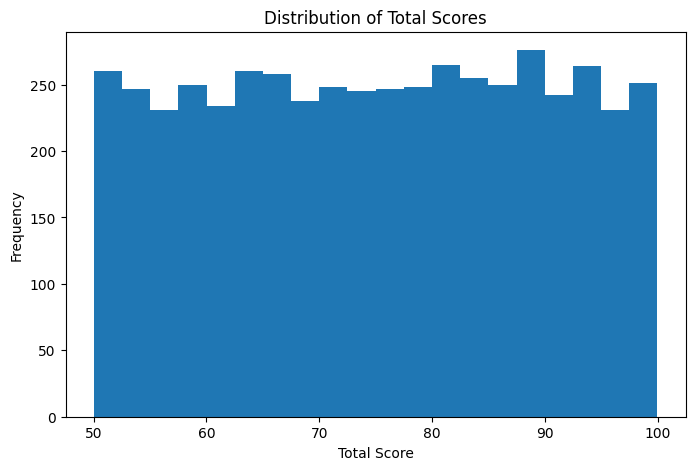

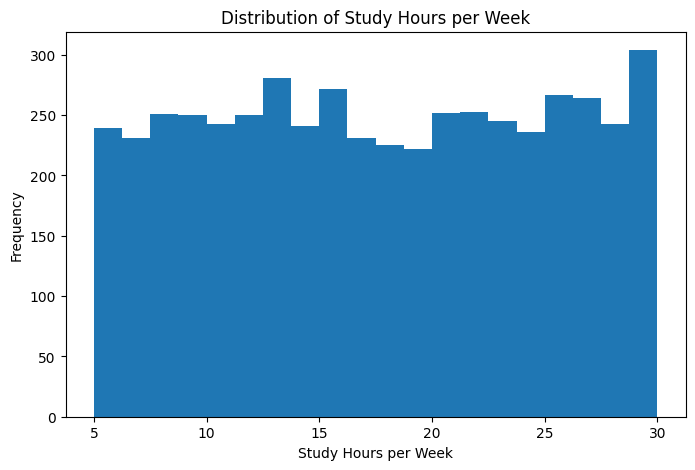

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Total_Score"], bins=20)
plt.title("Distribution of Total Scores")
plt.xlabel("Total Score")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df_clean["Study_Hours_per_Week"], bins=20)
plt.title("Distribution of Study Hours per Week")
plt.xlabel("Study Hours per Week")
plt.ylabel("Frequency")
plt.show()

## Classification Model

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Copy dataset (so original stays untouched)
df_model = df.copy()

# Encode categorical columns
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

# Features and target
X = df_model.drop("Grade", axis=1)
y = df_model["Grade"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.378

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.71      0.63       298
           1       0.22      0.13      0.16       180
           2       0.20      0.17      0.18       161
           3       0.31      0.41      0.35       176
           4       0.30      0.24      0.26       185

    accuracy                           0.38      1000
   macro avg       0.32      0.33      0.32      1000
weighted avg       0.35      0.38      0.36      1000



## Export Preprocessed Dataset

In [17]:
df_final.to_csv("preprocessed_students_grading_dataset.csv", index=False)
print("Saved!")

Saved!
